# Customer Churn Analysis: Key Drivers of Attrition

## Business Problem

Customer churn is a key driver of revenue loss for subscription-based telecom companies, making customer retention a critical business priority. Acquiring new customers is typically more expensive than retaining existing ones, so understanding the factors that influence churn is essential for improving profitability and long-term stability. This project analyzes customer-level data to identify which factors are most strongly associated with churn and to uncover patterns that can inform retention strategies.

## Data Overview

In [1]:
import pandas as pd
df = pd.read_csv("telco-churn.csv")

The dataset used in this analysis was obtained from Kaggle and contains 7,043 customer records with 21 features describing customer demographics, account information, and service usage. Each row represents a unique telecom customer, with the target variable Churn indicating whether a customer discontinued service (Yes/No), making this a binary classification problem.

The dataset includes both numerical and categorical variables capturing customer characteristics such as tenure, monthly charges, contract type, and service subscriptions. These features are used to understand customer behavior and identify patterns associated with churn. The dataset is structured to support predictive modeling and is used in this project to build and evaluate a binary classification model for customer churn prediction.

## Data Cleaning

In [78]:
import pandas as pd

# 1. Make a clean modeling copy (ONLY use this going forward)
df_model = df.copy()

# --- Fix TotalCharges properly ---
df_model["TotalCharges"] = df_model["TotalCharges"].astype(str).str.strip()
df_model["TotalCharges"] = df_model["TotalCharges"].replace(["", " "], pd.NA)
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

# Drop missing values AFTER conversion
df_model = df_model.dropna(subset=["TotalCharges"])

# --- Convert target variable ---
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# --- Drop ID column ---
df_model = df_model.drop("customerID", axis=1)

# --- One-hot encode ONLY categorical columns ---
categorical_cols = df_model.select_dtypes(include=["object"]).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# --- Final sanity checks ---
print(df_model.shape)
print("Missing values:", df_model.isnull().sum().sum())

(7032, 34)
Missing values: 0


## Methods

For this project, a telecom customer churn dataset obtained from Kaggle was used to analyze customer behavior and predict customer churn. The target variable was Churn, indicating whether a customer discontinued service.

The data was prepared by removing non-predictive identifier variables, checking for missing values, and ensuring variables were properly formatted for analysis. Categorical variables were encoded for modeling, and the dataset was split into training and test sets for model evaluation. Exploratory data analysis (EDA) was then conducted to examine the relationship between key variables and churn. For categorical variables, churn rates were compared across categories. For numerical variables, summary statistics such as mean and median were analyzed, along with distribution patterns, to identify differences between churned and retained customers.

A logistic regression model was selected because churn is a binary classification problem and the model provides interpretable coefficients for understanding predictor influence. The model was fit using the training data and evaluated on the test set using classification metrics including accuracy, precision, recall, F1-score, confusion matrix analysis, and ROC-AUC.

Exploratory data analysis was used to identify patterns and trends in the raw data, while the logistic regression model quantified the relationship between predictor variables and churn after controlling for other factors. Regression coefficients and odds ratios were interpreted to identify the strongest positive and negative predictors of churn, while also highlighting variables with minimal predictive impact.

Findings from both the exploratory and modeling analyses were used to generate business insights and recommendations aimed at identifying customer risk factors and supporting strategies to reduce churn.

## Exploratory Data Analysis

### Churn Overview (Overall Churn Rate)

In [79]:
# Count churn values
churn_counts = df["Churn"].value_counts()

# Calculate percentages
churn_pct = df["Churn"].value_counts(normalize=True) * 100

# Combine into one table
churn_summary = pd.DataFrame({"Count": churn_counts,"Percentage": churn_pct.round(2)})
churn_summary

,Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


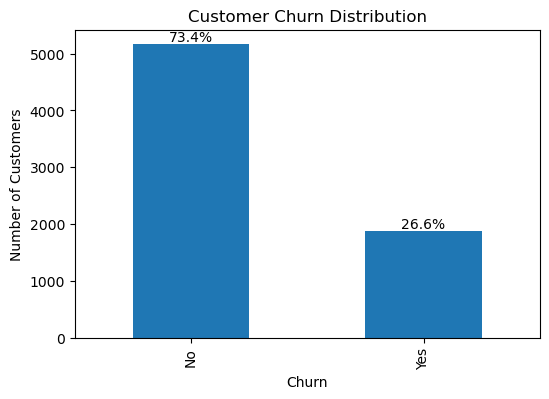

In [69]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

ax = churn_counts.plot(kind="bar", figsize=(6,4))

for i, v in enumerate(churn_counts):
    ax.text(i, v + 50, f"{churn_pct.iloc[i]:.1f}%", ha="center")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Figure 1.** Customer Churn Distribution

Figure 1 shows that approximately 26.6% of customers have churned, while 73.4% have remained with the company. This indicates a moderate class imbalance, with a larger proportion of retained customers compared to churned customers. This imbalance is important to consider when evaluating model performance, particularly for classification metrics beyond accuracy.

### Categorical Analysis

In [70]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

internet_churn["churn_rate_pct"] = (
    internet_churn["churn_count"] / internet_churn["total"] * 100
)

internet_churn.sort_values("churn_rate_pct", ascending=False)

,InternetService,churn_count,no_churn_count,total,churn_rate_pct
1,Fiber optic,1297,1799,3096,41.892765
0,DSL,459,1957,2416,18.998344
2,No,113,1407,1520,7.434211


**Figure 2.** Churn Rate by Internet Service Type

Churn rates vary significantly across internet service types. Customers using fiber optic service exhibit the highest churn rate at approximately 41.9%, which is substantially higher than DSL customers at 19.0% and customers with no internet service at 7.4%.

This suggests that fiber optic users represent a high-risk segment for churn. The difference in churn rates indicates that service type is a strong predictor of customer retention and may reflect differences in pricing, service quality, or customer expectations across plans.

In [71]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

contract_churn["churn_rate_pct"] = (
    contract_churn["churn_count"] / contract_churn["total"] * 100
).round(2)

contract_churn.sort_values("churn_rate_pct", ascending=False)

,Contract,churn_count,no_churn_count,total,churn_rate_pct
0,Month-to-month,1655,2220,3875,42.71
1,One year,166,1306,1472,11.28
2,Two year,48,1637,1685,2.85


**Figure 3.** Churn Rate by Contract Type

Contract type shows a very strong relationship with churn. Customers on month-to-month contracts have a significantly higher churn rate at 42.7%, compared to 11.3% for one-year contracts and only 2.9% for two-year contracts.

This suggests that contract length is a strong predictor of customer retention. Longer-term contracts are associated with substantially lower churn, likely due to increased commitment and switching costs. This makes contract structure a key lever for improving customer retention.

In [5]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

payment_churn["churn_rate_pct"] = (
    payment_churn["churn_count"] / payment_churn["total"] * 100
).round(2)

payment_churn.sort_values("churn_rate_pct", ascending=False)

,PaymentMethod,churn_count,no_churn_count,total,churn_rate_pct
2,Electronic check,1071,1294,2365,45.29
3,Mailed check,308,1296,1604,19.20
0,Bank transfer (automatic),258,1284,1542,16.73
1,Credit card (automatic),232,1289,1521,15.25


**Figure 4.** Churn Rate by Payment Method

Payment method is also associated with differences in churn behavior. Customers using electronic check have the highest churn rate at approximately 45.3%, compared to 15.2% for credit card (automatic) users and 16.3% for mailed check users. This suggests that payment method may reflect differences in customer engagement or convenience, with electronic check users being significantly more likely to churn. Automated payment methods appear to be associated with improved retention, potentially due to reduced difficulty in the billing process.

In [6]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

paperless_churn["churn_rate_pct"] = (
    paperless_churn["churn_count"] / paperless_churn["total"] * 100
).round(2)

paperless_churn.sort_values("churn_rate_pct", ascending=False)

,PaperlessBilling,churn_count,no_churn_count,total,churn_rate_pct
1,Yes,1400,2768,4168,33.59
0,No,469,2395,2864,16.38


**Figure 5.** Churn Rate by Paperless Billing Status

Customers who use paperless billing have a higher churn rate (33.6%) compared to those who do not (16.4%). This indicates that paperless billing is associated with increased churn risk and may reflect differences in customer behavior or engagement

In [7]:
gender_churn = (
    df.groupby("gender")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

gender_churn["churn_rate_pct"] = (
    gender_churn["churn_count"] / gender_churn["total"] * 100
).round(2)

gender_churn.sort_values("churn_rate_pct", ascending=False)

,gender,churn_count,no_churn_count,total,churn_rate_pct
0,Female,939,2544,3483,26.96
1,Male,930,2619,3549,26.20


**Figure 6.** Churn Rate by Gender

Churn rates are nearly identical between genders, with females at 27.0% and males at 26.2%. This suggests that gender has little to no meaningful relationship with churn in this dataset.

In [11]:
phoneservice_churn = (
    df.groupby("PhoneService")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

phoneservice_churn["churn_rate_pct"] = (
    phoneservice_churn["churn_count"] / phoneservice_churn["total"] * 100
).round(2)

phoneservice_churn.sort_values("churn_rate_pct", ascending=False)

,PhoneService,churn_count,no_churn_count,total,churn_rate_pct
1,Yes,1699,4653,6352,26.75
0,No,170,510,680,25.00


**Figure 7.** Churn Rate by Phone Service

Churn rates are also very similarly insignificant between customers with and without phone service, at 26.8% and 25.0% respectively.

In [12]:
multilines_churn = (
    df.groupby("MultipleLines")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

multilines_churn["churn_rate_pct"] = (
    multilines_churn["churn_count"] / multilines_churn["total"] * 100
).round(2)

multilines_churn.sort_values("churn_rate_pct", ascending=False)

,MultipleLines,churn_count,no_churn_count,total,churn_rate_pct
2,Yes,850,2117,2967,28.65
0,No,849,2536,3385,25.08
1,No phone service,170,510,680,25.00


**Figure 8.** Churn Rate by Multiple Lines

Churn rates across multiple lines categories are relatively similar, with values ranging from 25.0% to 28.7%. This suggests that multiple lines has a weak relationship with churn.

In [17]:
streamingtv_churn = (
    df.groupby("StreamingTV")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

streamingtv_churn["churn_rate_pct"] = (
    streamingtv_churn["churn_count"] / streamingtv_churn["total"] * 100
).round(2)

streamingtv_churn.sort_values("churn_rate_pct", ascending=False)

,StreamingTV,churn_count,no_churn_count,total,churn_rate_pct
0,No,942,1867,2809,33.54
2,Yes,814,1889,2703,30.11
1,No internet service,113,1407,1520,7.43


**Figure 9.** Churn Rate by Streaming TV Service

Customers without Streaming TV have the highest churn rate at 33.5%, followed by those with the service at 30.1%. Customers with no internet service have a much lower churn rate at 7.4%, though this group represents a fundamentally different customer segment. Overall, Streaming TV service shows a weak relationship with churn and does not appear to be a primary driver.

In [18]:
streamingmovies_churn = (
    df.groupby("StreamingMovies")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

streamingmovies_churn["churn_rate_pct"] = (
    streamingmovies_churn["churn_count"] / streamingmovies_churn["total"] * 100
).round(2)

streamingmovies_churn.sort_values("churn_rate_pct", ascending=False)

,StreamingMovies,churn_count,no_churn_count,total,churn_rate_pct
0,No,938,1843,2781,33.73
2,Yes,818,1913,2731,29.95
1,No internet service,113,1407,1520,7.43


**Figure 10.** Churn Rate by Streaming Movies Service

Churn rates for Streaming Movies follow a similar pattern to Streaming TV. Customers without the service have the highest churn rate at 33.7%, followed by customers with the service at 30.0%. Customers with no internet service again show a much lower churn rate at 7.4%. Overall, Streaming Movies shows a weak relationship with churn and is not a major driver.

In [8]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

senior_churn["churn_rate_pct"] = (
    senior_churn["churn_count"] / senior_churn["total"] * 100
).round(2)

senior_churn.sort_values("churn_rate_pct", ascending=False)

,SeniorCitizen,churn_count,no_churn_count,total,churn_rate_pct
1,1,476,666,1142,41.68
0,0,1393,4497,5890,23.65


**Figure 11.** Churn Rate by Senior Citizen Status

Senior citizens show a significantly higher churn rate (41.7%) compared to non-senior customers (23.7%). This indicates that age group is associated with meaningful differences in churn behavior, with senior customers being a higher-risk segment. This may reflect differences in service needs, pricing sensitivity, or satisfaction levels between age groups. 

In [9]:
partner_churn = (
    df.groupby("Partner")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

partner_churn["churn_rate_pct"] = (
    partner_churn["churn_count"] / partner_churn["total"] * 100
).round(2)

partner_churn.sort_values("churn_rate_pct", ascending=False)

,Partner,churn_count,no_churn_count,total,churn_rate_pct
0,No,1200,2439,3639,32.98
1,Yes,669,2724,3393,19.72


**Figure 12.** Churn Rate by Partner Status

Customers without a partner have a higher churn rate (33.0%) compared to those with a partner (19.7%). This suggests that customers with partners are less likely to churn, potentially indicating greater household stability or stronger long-term commitment to the service.

In [10]:
dependents_churn = (
    df.groupby("Dependents")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

dependents_churn["churn_rate_pct"] = (
    dependents_churn["churn_count"] / dependents_churn["total"] * 100
).round(2)

dependents_churn.sort_values("churn_rate_pct", ascending=False)

,Dependents,churn_count,no_churn_count,total,churn_rate_pct
0,No,1543,3390,4933,31.28
1,Yes,326,1773,2099,15.53


**Figure 13.** Churn Rate by Dependents Status

Customers without dependents have a higher churn rate (31.3%) compared to those with dependents (15.5%). This suggests that customers with dependents are significantly less likely to churn, potentially reflecting greater household stability and stronger long-term service commitment.

In [13]:
onlinesecurity_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

onlinesecurity_churn["churn_rate_pct"] = (
    onlinesecurity_churn["churn_count"] / onlinesecurity_churn["total"] * 100
).round(2)

onlinesecurity_churn.sort_values("churn_rate_pct", ascending=False)

,OnlineSecurity,churn_count,no_churn_count,total,churn_rate_pct
0,No,1461,2036,3497,41.78
2,Yes,295,1720,2015,14.64
1,No internet service,113,1407,1520,7.43


**Figure 14.** Churn Rate by Online Security Status

Online Security shows a strong relationship with churn. Customers without online security have a significantly higher churn rate (41.8%) compared to those with the service (14.6%). Customers with no internet service again show a lower churn rate (7.4%), reflecting a distinct customer segment. This suggests that the presence of online security is associated with substantially improved customer retention.

In [14]:
onlinebackup_churn = (
    df.groupby("OnlineBackup")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

onlinebackup_churn["churn_rate_pct"] = (
    onlinebackup_churn["churn_count"] / onlinebackup_churn["total"] * 100
).round(2)

onlinebackup_churn.sort_values("churn_rate_pct", ascending=False)

,OnlineBackup,churn_count,no_churn_count,total,churn_rate_pct
0,No,1233,1854,3087,39.94
2,Yes,523,1902,2425,21.57
1,No internet service,113,1407,1520,7.43


**Figure 15.** Churn Rate by Online Backup Status

Online Backup shows a clear association with churn. Customers without online backup have a higher churn rate (39.9%) compared to those with the service (21.6%). Customers with no internet service again show a lower churn rate (7.4%). This suggests that customers who utilize backup services are less likely to churn, indicating that additional service adoption is associated with improved retention.

In [15]:
deviceprotection_churn = (
    df.groupby("DeviceProtection")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

deviceprotection_churn["churn_rate_pct"] = (
    deviceprotection_churn["churn_count"] / deviceprotection_churn["total"] * 100
).round(2)

deviceprotection_churn.sort_values("churn_rate_pct", ascending=False)

,DeviceProtection,churn_count,no_churn_count,total,churn_rate_pct
0,No,1211,1883,3094,39.14
2,Yes,545,1873,2418,22.54
1,No internet service,113,1407,1520,7.43


**Figure 16.** Churn Rate by Device Protection Status

Device Protection shows a similar pattern to other add-on services. Customers without device protection have a higher churn rate (39.1%) compared to those with the service (22.5%). Customers with no internet service again exhibit a lower churn rate (7.4%), representing a separate segment. This suggests that adoption of device protection is associated with lower churn, reinforcing the broader pattern that customers using additional service features are more likely to be retained.

In [72]:
techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
    .agg(
        churn_count=lambda x: (x == "Yes").sum(),
        no_churn_count=lambda x: (x == "No").sum(),
        total="count"
    )
    .reset_index()
)

techsupport_churn["churn_rate_pct"] = (
    techsupport_churn["churn_count"] / techsupport_churn["total"] * 100
).round(2)

techsupport_churn.sort_values("churn_rate_pct", ascending=False)

,TechSupport,churn_count,no_churn_count,total,churn_rate_pct
0,No,1446,2026,3472,41.65
2,Yes,310,1730,2040,15.20
1,No internet service,113,1407,1520,7.43


**Figure 17.** Churn Rate by Tech Support Status

Tech Support shows a strong relationship with churn. Customers without tech support have a significantly higher churn rate (41.7%) compared to those with the service (15.2%). Customers with no internet service again show a lower churn rate (7.4%). This indicates that access to tech support is associated with substantially improved customer retention and is one of the strongest add-on service indicators of churn risk reduction.

### Numeric Analysis

In [19]:
df.groupby("Churn")["tenure"].agg(["mean", "median"])

,mean,median
Churn,,
No,37.650010,38.0
Yes,17.979133,10.0


**Figure 18.** Tenure Summary by Churn Status

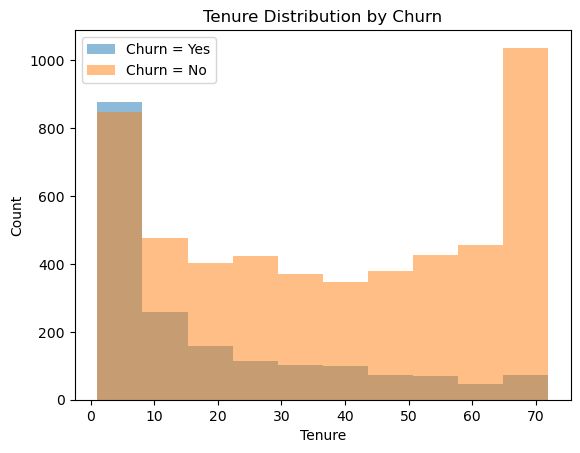

In [73]:
import matplotlib.pyplot as plt

plt.hist(df[df["Churn"] == "Yes"]["tenure"], alpha=0.5, label="Churn = Yes")
plt.hist(df[df["Churn"] == "No"]["tenure"], alpha=0.5, label="Churn = No")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.legend()
plt.show()

**Figure 19.** Tenure Distribution by Churn Status

Customers who churned have significantly lower tenure compared to those who did not churn. The average tenure for churned customers is approximately 18 months, with a median of 10 months, while non-churned customers have an average tenure of about 37.7 months and a median of 38 months. This indicates that churn is heavily concentrated among newer customers, suggesting that early customer experience is a critical period for retention.

In [21]:
import pandas as pd

bins = [0, 6, 12, 24, 48, df["tenure"].max()]
labels = ["0–6", "6–12", "12–24", "24–48", "48+"]

df["tenure_bucket"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

In [22]:
tenure_summary = df.groupby("tenure_bucket", observed=False)["Churn"].value_counts().unstack()

tenure_summary["Churn_Rate"] = tenure_summary["Yes"] / (tenure_summary["Yes"] + tenure_summary["No"]) * 100

tenure_summary

Churn,No,Yes,Churn_Rate
tenure_bucket,,,
0–6,686,784,53.333333
6–12,452,253,35.886525
12–24,730,294,28.710938
24–48,1269,325,20.388959
48+,2026,213,9.513176


**Figure 20.** Churn Rate by Tenure Bucket (Summary Table)

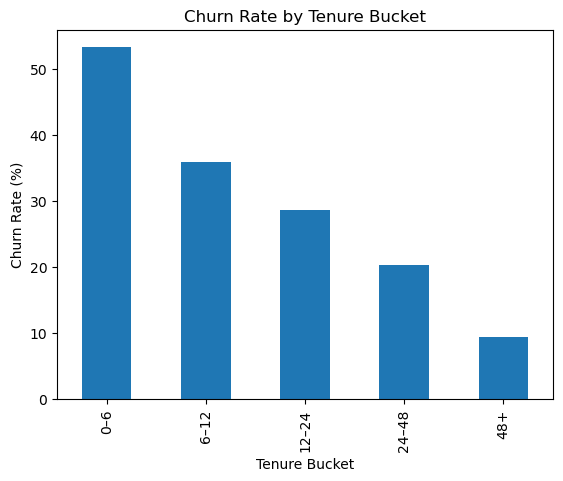

In [23]:
import matplotlib.pyplot as plt

tenure_summary["Churn_Rate"].plot(kind="bar")

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.ylabel("Churn Rate (%)")
plt.show()

**Figure 21.** Churn Rate by Tenure Bucket (Bar Chart)

As seen in Figure 21, churn rate decreases steadily as customer tenure increases. Customers in the 0–6 month bucket have the highest churn rate at 53.3%, which declines consistently across each tenure group, reaching 9.5% for customers with 48+ months of tenure. This shows that churn is heavily concentrated among newer customers, with retention improving significantly as customer tenure increases. Early-stage customers represent the highest-risk segment for churn.

In [24]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,61.307408,64.45
Yes,74.441332,79.65


**Figure 22.** Monthly Charges Summary by Churn Status (Summary Table)

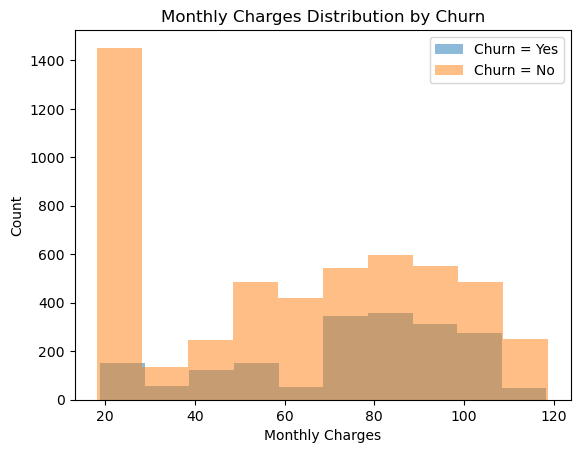

In [25]:
import matplotlib.pyplot as plt

plt.hist(df[df["Churn"] == "Yes"]["MonthlyCharges"], alpha=0.5, label="Churn = Yes")
plt.hist(df[df["Churn"] == "No"]["MonthlyCharges"], alpha=0.5, label="Churn = No")

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.legend()
plt.show()

**Figure 23.** Monthly Charges Summary by Churn Status (Histogram)

Customers who churned have higher monthly charges compared to those who did not churn. The average monthly charge for churned customers is 74.4, with a median of 79.7, while non-churned customers have a lower average of 61.3 and a median of 64.5. This suggests that higher monthly costs are associated with increased churn risk, indicating potential price sensitivity within the customer base.

In [26]:
#Dividing into Quartiles
df["monthly_bucket_q"] = pd.qcut(df["MonthlyCharges"], q=4)

In [27]:
monthly_summary = df.groupby("monthly_bucket_q", observed=False)["Churn"].value_counts().unstack()

monthly_summary["Churn_Rate"] = (monthly_summary["Yes"] / (monthly_summary["Yes"] + monthly_summary["No"]) * 100)

monthly_summary

Churn,No,Yes,Churn_Rate
monthly_bucket_q,,,
"(18.249, 35.588]",1559,199,11.319681
"(35.588, 70.35]",1328,433,24.588302
"(70.35, 89.862]",1096,659,37.549858
"(89.862, 118.75]",1180,578,32.878271


**Figure 24.** Churn Rate by Monthly Charges Bucket (Summary Table)

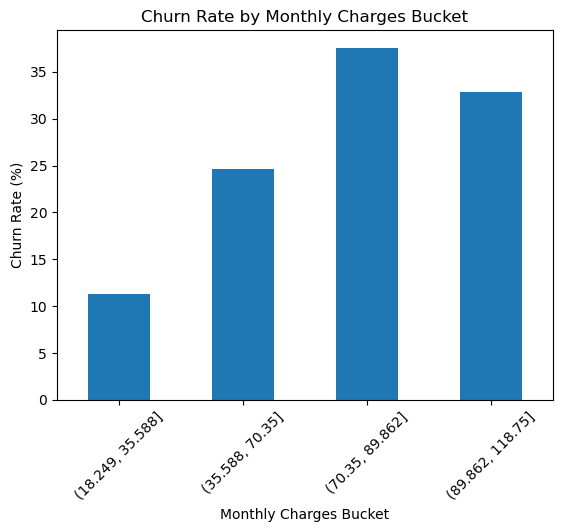

In [28]:
import matplotlib.pyplot as plt

churn_rate = df.groupby("monthly_bucket_q", observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

churn_rate.plot(kind="bar")

plt.title("Churn Rate by Monthly Charges Bucket")
plt.xlabel("Monthly Charges Bucket")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

**Figure 25.** Churn Rate by Monthly Charges Bucket (Bar Chart)

Churn rate generally increases as monthly charges rise. Customers in the lowest pricing bucket (18.25–35.59) have the lowest churn rate at 11.3%, while higher pricing buckets show substantially higher churn rates, peaking at 37.5% in the 70.35–89.86 range. This suggests that customers paying higher monthly fees are more likely to churn, indicating potential price sensitivity and perceived value differences across pricing tiers.

In [29]:
df.groupby("Churn")["TotalCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,2555.344141,1683.60
Yes,1531.796094,703.55


**Figure 26.** Total Charges Summary by Churn Status (Summary Table)

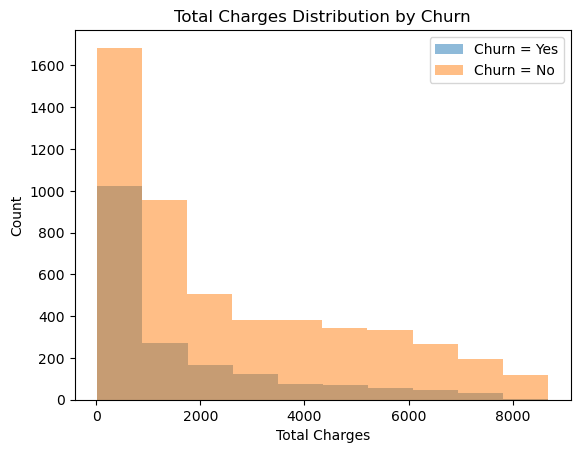

In [30]:
import matplotlib.pyplot as plt

plt.hist(df[df["Churn"] == "Yes"]["TotalCharges"], alpha=0.5, label="Churn = Yes")
plt.hist(df[df["Churn"] == "No"]["TotalCharges"], alpha=0.5, label="Churn = No")

plt.title("Total Charges Distribution by Churn")
plt.xlabel("Total Charges")
plt.ylabel("Count")
plt.legend()
plt.show()

**Figure 27.** Total Charges Summary by Churn Status (Histogram)

Customers who churned have substantially lower total charges compared to those who did not churn. The average total charges for churned customers is 1,531.8, with a median of 703.6, while non-churned customers have a much higher average of 2,555.3 and a median of 1,683.6. This indicates that churned customers tend to have shorter customer lifespans, resulting in lower accumulated charges over time.

In [31]:
#Dividing into Quartiles
df["total_bucket_q"] = pd.qcut(df["TotalCharges"], q=4)

In [32]:
total_summary = df.groupby("total_bucket_q", observed=False)["Churn"].value_counts().unstack()

total_summary["Churn_Rate"] = (total_summary["Yes"] / (total_summary["Yes"] + total_summary["No"]) * 100)

total_summary

Churn,No,Yes,Churn_Rate
total_bucket_q,,,
"(18.799, 401.45]",994,764,43.458476
"(401.45, 1397.475]",1313,445,25.312856
"(1397.475, 3794.738]",1353,405,23.037543
"(3794.738, 8684.8]",1503,255,14.505119


**Figure 28.** Churn Rate by Total Charges Bucket (Summary Table)

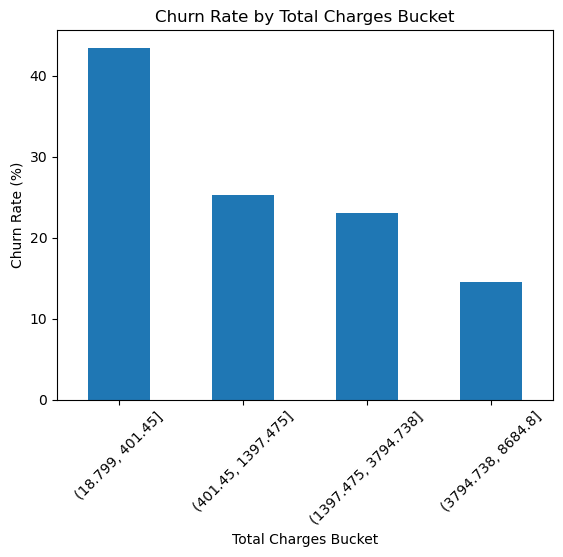

In [33]:
import matplotlib.pyplot as plt

churn_rate = df.groupby("total_bucket_q", observed=False)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

churn_rate.plot(kind="bar")

plt.title("Churn Rate by Total Charges Bucket")
plt.xlabel("Total Charges Bucket")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

**Figure 29.** Churn Rate by Total Charges Bucket (Bar Chart)

Figure 29 shows that churn rate decreases as total charges increase. Customers in the lowest total charges bucket (18.8–401.45) have the highest churn rate at 43.5%, while customers in the highest bucket (3794.74–8684.8) have a much lower churn rate of 14.5%. This pattern reflects the relationship between customer tenure and churn, since total charges accumulate over time. Customers with lower total charges are generally newer and therefore more likely to churn.

## Key Insights

- Contract type was the strongest driver of churn, with month-to-month customers showing dramatically higher churn rates than customers on one- or two-year contracts.

- Customer tenure was one of the most important predictors of churn, with churn heavily concentrated during the first 6 to 12 months of service.

- Internet service type was strongly associated with churn, with fiber optic customers exhibiting higher churn rates than DSL and no-internet customers.

- Higher monthly charges were associated with increased churn risk, suggesting some degree of price sensitivity within the customer base.

- Value-added services such as Online Security, Tech Support, Online Backup, and Device Protection were consistently associated with lower churn rates.

- Payment method also showed a meaningful relationship with churn, with electronic check users exhibiting significantly higher churn rates than customers using automated payment methods.

- Several variables demonstrated little to no relationship with churn, including gender, phone service, multiple lines, and streaming services.

## Modeling

### Model Selection

Logistic regression was selected for this analysis because the objective is to predict a binary outcome (customer churn) while maintaining interpretability of the model. While more complex models may achieve slightly higher predictive performance, logistic regression was selected because interpretability was a primary objective of this analysis.

This is particularly important in a business context, where understanding the key drivers of churn is as valuable as prediction accuracy. Additionally, logistic regression serves as a strong baseline model for binary classification problems and performs well when relationships between variables are approximately linear in the log-odds space.

While more complex models such as tree-based methods could potentially improve predictive performance, logistic regression was prioritized to ensure transparency and interpretability of results.

### Train/Test Split

The dataset was split into training and testing sets using an 80/20 split. A stratified sampling approach was used to preserve the original distribution of the target variable across both sets. This ensures that both the training and testing datasets maintain a similar proportion of churned and non-churned customers, improving the reliability of model evaluation. 

The logistic regression model was trained using the training dataset. The fitted model was then used to generate predictions on the test set for evaluation.

### Feature Scaler

Numerical features including tenure, MonthlyCharges, and TotalCharges were standardized using StandardScaler. This step ensures that variables with larger numerical ranges do not disproportionately influence the logistic regression model.

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# STEP 1: Clean modeling dataset
df_model = df.copy()
df_model = df_model.drop(
    ["customerID", "tenure_bucket", "monthly_bucket_q", "total_bucket_q"],
    axis=1,
    errors="ignore"
)

df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# STEP 2: Split X and y
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# STEP 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 4: One-hot encode AFTER split (important improvement)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# STEP 5: Align train and test
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# STEP 6: Scale numeric columns ONLY
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fit model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Evaluation

The performance of the logistic regression model was evaluated using multiple classification metrics to assess both overall accuracy and its ability to correctly identify churned customers.

The following evaluation metrics were used:
- Accuracy: overall correctness of predictions
- Precision: proportion of predicted churn cases that were correct
- Recall: ability to correctly identify actual churn cases
- F1-score: balance between precision and recall
- ROC-AUC: model’s ability to distinguish between classes

The confusion matrix below shows the distribution of correct and incorrect predictions across churn and non-churn classes.

#### Logistic Regression (Baseline Model)

In [63]:
# 2. Predict
y_pred = model.predict(X_test)

# 3. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8045486851457001

Confusion Matrix:
 [[918 115]
 [160 214]]

Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



The performance of the logistic regression model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix to assess both overall performance and class-specific behavior.

The model achieved an accuracy of **80.5%**, indicating that it correctly classified approximately four out of five customers in the test set. While this reflects strong overall performance, accuracy alone does not fully capture performance due to class imbalance in the dataset.

The confusion matrix shows that the model correctly identified 918 non-churn customers and 214 churn customers. However, it misclassified 160 actual churn cases as non-churn, indicating that some at-risk customers were not successfully detected.

The classification report further highlights this imbalance in predictive performance. The model performs well for non-churn customers, with an F1-score of 0.87, but performance is lower for churned customers, with an F1-score of 0.61. This is primarily driven by lower recall for the churn class (0.57), meaning the model misses a portion of actual churn cases.

Overall, the model provides a solid baseline for churn prediction, with strong general performance but room for improvement in identifying churned customers.

#### Logistic Regression (Class-Weighted Model)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# New model with class weighting
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_balanced))
print("\nClassification Report:\n", classification_report(y_test, y_pred_balanced))

Accuracy: 0.7256574271499645

Confusion Matrix:
 [[724 309]
 [ 77 297]]

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



#### ROC-AUC Analysis (Class-Weighted Model)

ROC-AUC: 0.834


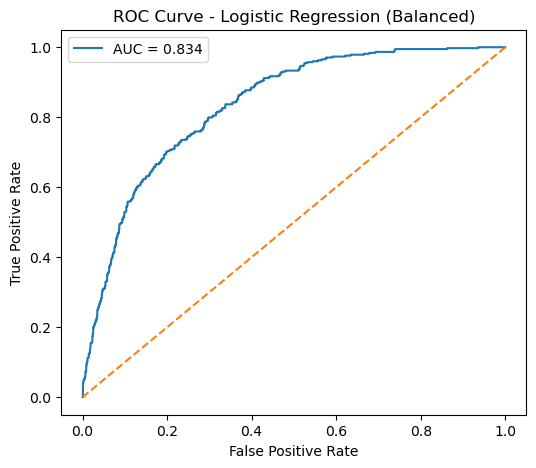

In [89]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# align test set to training columns (CRITICAL STEP)
X_test_aligned = X_test.reindex(columns=model_balanced.feature_names_in_, fill_value=0)

# predicted probabilities
y_probs = model_balanced.predict_proba(X_test_aligned)[:, 1]

# ROC-AUC score
auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", round(auc, 3))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Balanced)")
plt.legend()
plt.show()

**Figure 30.** ROC curve for the class-weighted logistic regression model used for churn prediction.

#### ROC-AUC Analysis Summary

The class-weighted logistic regression model achieved a ROC-AUC score of **0.834**, shown in Figure 30, indicating strong discriminatory power between churned and non-churned customers.

An AUC of 0.834 means that, when randomly selecting one churned customer and one non-churned customer, the model will correctly assign a higher churn probability to the churned customer approximately 83.4% of the time.

This demonstrates that the model is not only performing well at a fixed classification threshold (such as 0.5), but is also effective at ranking customers by churn risk across all possible thresholds. The ROC curve visually confirms this performance, as it remains well above the diagonal baseline representing random classification.

#### Model Summary
To address class imbalance in the dataset, a class-weighted logistic regression model was implemented to improve the detection of churned customers.

The model achieved an accuracy of 72.6%, which is lower than the baseline model. However, this decrease in overall accuracy is expected, as the class weighting shifts the model toward better identifying the minority class (churned customers).

The confusion matrix shows improved detection of churn cases, with 297 correctly identified churned customers compared to 77 missed churn cases. This represents a significant improvement in recall for the churn class compared to the baseline model.

The classification report further highlights this tradeoff. Recall for churned customers increased to 0.79, meaning the model is now much better at identifying customers who are likely to churn. However, this comes at the cost of lower precision (0.49), indicating more false positives.

In addition to classification metrics, the model achieved a ROC-AUC score of 0.834, indicating strong ability to distinguish between churned and non-churned customers across all classification thresholds. This shows that beyond a fixed decision boundary, the model is also effective at ranking customers by churn risk.

Overall, the class-weighted model improves the model’s ability to identify at-risk customers, making it more suitable for churn prevention use cases where capturing potential churners is more important than overall accuracy.

## Results

The logistic regression model was used to identify the most important drivers of customer churn based on the magnitude and direction of model coefficients.

The results, as seen in Figure 31, show that contract type is the strongest predictor of churn. Customers on month-to-month contracts are significantly more likely to churn compared to those on one-year or two-year contracts. This suggests that lack of long-term commitment is a major risk factor for customer attrition.

Tenure is also a strong negative predictor of churn, indicating that customers are most likely to churn early in their relationship with the company. This reinforces the importance of early-tenure retention strategies.

Internet service type is another key driver, with fiber optic customers exhibiting higher churn likelihood compared to DSL and no-internet customers. This may reflect differences in pricing, perceived value, or service quality within this segment.

Add-on services such as Online Security, Tech Support, Online Backup, and Device Protection are consistently associated with lower churn probability. This suggests that customers who adopt more services are more engaged and less likely to leave.

Payment method also plays a meaningful role, with electronic check users showing higher churn risk compared to customers using automated payment methods. This may indicate differences in customer stability or payment friction.

Demographic variables such as gender and phone service show minimal predictive value, while household-related variables such as partner and dependents have only a weak influence on churn behavior.

Overall, the results indicate that churn is primarily driven by customer commitment (contract and tenure), service experience (internet type and add-on services), and payment behavior. These findings closely align with the exploratory data analysis and are further supported by the logistic regression model results.

In [61]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model_balanced.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)
coef_df_sorted = coef_df.sort_values(by="Abs_Coefficient", ascending=False)
coef_df_sorted

,Feature,Coefficient,Abs_Coefficient
4,Contract_Two year,-1.456973,1.456973
0,tenure,-1.253034,1.253034
8,InternetService_Fiber optic,1.134813,1.134813
3,Contract_One year,-0.788478,0.788478
2,TotalCharges,0.606596,0.606596
1,MonthlyCharges,-0.485947,0.485947
19,PaymentMethod_Electronic check,0.411009,0.411009
26,StreamingTV_Yes,0.386970,0.386970
21,PhoneService_Yes,-0.373091,0.373091
24,StreamingMovies_Yes,0.371653,0.371653


**Figure 31.** Top positive and negative predictors of customer churn based on logistic regression coefficients.

In [62]:
coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
8,InternetService_Fiber optic,1.134813,1.134813
2,TotalCharges,0.606596,0.606596
19,PaymentMethod_Electronic check,0.411009,0.411009
26,StreamingTV_Yes,0.386970,0.386970
24,StreamingMovies_Yes,0.371653,0.371653
11,MultipleLines_Yes,0.336625,0.336625
16,PaperlessBilling_Yes,0.256172,0.256172
22,SeniorCitizen_1,0.205044,0.205044
7,DeviceProtection_Yes,0.072508,0.072508
18,PaymentMethod_Credit card (automatic),0.071101,0.071101


**Figure 32.** Feature importance ranking of churn drivers (sorted by magnitude)

## Business Recommendations

The data analysis revealed several clear patterns and key drivers of customer churn, providing meaningful opportunities for improving retention and optimizing business operations.

The strongest driver of churn was contract length, with shorter contracts associated with significantly higher churn rates. This suggests that lack of long-term commitment is the primary risk factor in customer retention.

The second major driver was customer tenure, where newer customers exhibited substantially higher churn rates compared to long-term customers. This indicates that the early stage of the customer lifecycle is the most vulnerable period for churn, and improving onboarding or early customer experience could meaningfully reduce attrition.

The third core driver was internet service type, with fiber optic customers showing the highest churn rates. This may indicate dissatisfaction within this segment, potentially related to pricing, service expectations, or competitive alternatives, and warrants further investigation.

Secondary drivers of churn included monthly charges, payment method, and support-related services. Higher monthly charges were associated with increased churn risk, suggesting potential price sensitivity among customers. Customers using electronic check payments also showed higher churn rates, possibly reflecting lower payment convenience or weaker customer engagement. In contrast, the presence of support-related services such as Online Security and Tech Support was associated with lower churn, indicating that value-added services improve customer retention.

Several variables, including gender, phone service, multiple lines, and streaming TV or movies, showed minimal predictive value for churn and were not meaningful drivers in the analysis.

The logistic regression model reinforced the findings from the exploratory data analysis, particularly the importance of contract type, tenure, and internet service type as key predictors of churn. The class-weighted logistic regression model improved the identification of churned customers by addressing class imbalance, increasing the model’s ability to correctly detect high-risk customers even at the expense of overall accuracy. This tradeoff is expected in churn modeling, where correctly identifying at-risk customers is more important than overall classification accuracy.

Overall, retention strategies should prioritize early-tenure customers, particularly those on month-to-month contracts. Incentivizing longer-term contracts, improving the early customer experience, and addressing potential issues within fiber optic service customers may significantly reduce churn. Additionally, bundling support-related services and encouraging automated payment methods may further improve customer retention.

## Limitations and Future Work

The data analysis revealed several key relationships that generated actionable insights for reducing customer churn; however, several limitations should be considered when interpreting the results. The findings are specific to the customer population represented in this dataset and may not generalize to all telecommunications companies. Additionally, the analysis was limited to the variables available within the dataset, leaving open the possibility that other important drivers of churn were not captured. Factors such as customer satisfaction, service reliability, competitor offerings, and customer support interactions may also influence churn behavior but were not available for analysis.

From a modeling perspective, logistic regression assumes a linear relationship between the predictor variables and the log-odds of churn. While this provides an interpretable framework for understanding churn drivers, it may not fully capture more complex relationships or interactions between variables. The class-weighted model significantly improved the identification of churned customers, but some customers were still misclassified. This limitation is expected in predictive modeling and highlights that the model should be viewed as a decision-support tool rather than a foolproof prediction system.

In terms of interpretation, while the strongest predictors of churn were identified, these relationships do not establish causation. Although several variables demonstrated statistically meaningful relationships with churn, the underlying reasons for those relationships remain unproven. For example, fiber optic customers exhibited higher churn rates, but the analysis cannot determine whether this relationship is driven by pricing, service quality, customer expectations, or other unobserved factors.

Future work could explore more advanced modeling techniques, such as decision trees, random forests, or gradient boosting models, to determine whether predictive performance can be improved. Additional customer-level information and behavioral data could also be incorporated to better understand the underlying causes of churn and further improve model accuracy and business decision-making.